In [1]:
import numpy as np
import random

# -------------------------------------------------------------------
# 1. Coordinate conversion (bottom-left to numpy index)
# -------------------------------------------------------------------
def coord_to_index(x, y, H):
    return H - 1 - y, x

def index_to_coord(row, col, H):
    return col, H - 1 - row

# -------------------------------------------------------------------
# 2. GridWorld environment with bottom-left coordinates
# -------------------------------------------------------------------
class GridWorld:
    def __init__(self):
        self.H = 6
        self.W = 10

        # Rewards located using coordinate positions
        self.rewards = {
            (7, 4): 5,
            (2, 1): 3,
            (9, 3): -2
        }

        # Start at (3,3) as you used before
        self.start_state = (3, 3)
        self.state = self.start_state

        self.actions = {
            0: (0, 1),   # up
            1: (0, -1),  # down
            2: (-1, 0),  # left
            3: (1, 0),   # right
        }

    def reset(self):
        self.state = self.start_state
        return self.state

    def step(self, action):
        dx, dy = self.actions[action]
        x, y = self.state
        nx, ny = x + dx, y + dy

        # Boundary check
        if 0 <= nx < self.W and 0 <= ny < self.H:
            self.state = (nx, ny)

        reward = self.rewards.get(self.state, 0)

        # Terminal if land on a reward cell
        done = self.state in self.rewards

        return self.state, reward, done

# -------------------------------------------------------------------
# 3. Q-learning implementation
# -------------------------------------------------------------------
env = GridWorld()
Q = np.zeros((env.W, env.H, 4))  # Q[x,y,a]

alpha = 0.1
gamma = 0.99
epsilon = 0.1
episodes = 30000

def choose_action(state):
    if random.random() < epsilon:
        return random.randint(0, 3)
    x, y = state
    return np.argmax(Q[x, y])

for _ in range(episodes):
    s = env.reset()
    done = False

    while not done:
        a = choose_action(s)
        s2, r, done = env.step(a)

        x, y = s
        nx, ny = s2

        Q[x, y, a] += alpha * (r + gamma * np.max(Q[nx, ny]) - Q[x, y, a])
        s = s2

# -------------------------------------------------------------------
# 4. Generate policy arrows using bottom-left coordinates
# -------------------------------------------------------------------
arrow_map = {0: "↑", 1: "↓", 2: "←", 3: "→"}
grid_display = np.full((env.H, env.W), "", dtype=object)

for x in range(env.W):
    for y in range(env.H):
        row, col = coord_to_index(x, y, env.H)

        if (x, y) in env.rewards:
            grid_display[row, col] = f"({env.rewards[(x,y)]})"
        else:
            best_a = np.argmax(Q[x, y])
            grid_display[row, col] = arrow_map[best_a]

print(grid_display)


[['→' '→' '→' '→' '→' '→' '→' '↓' '←' '←']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '(5)' '↑' '↑']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '(-2)']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']
 ['↑' '↑' '(3)' '↑' '↑' '↑' '↑' '↑' '↑' '↑']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']]


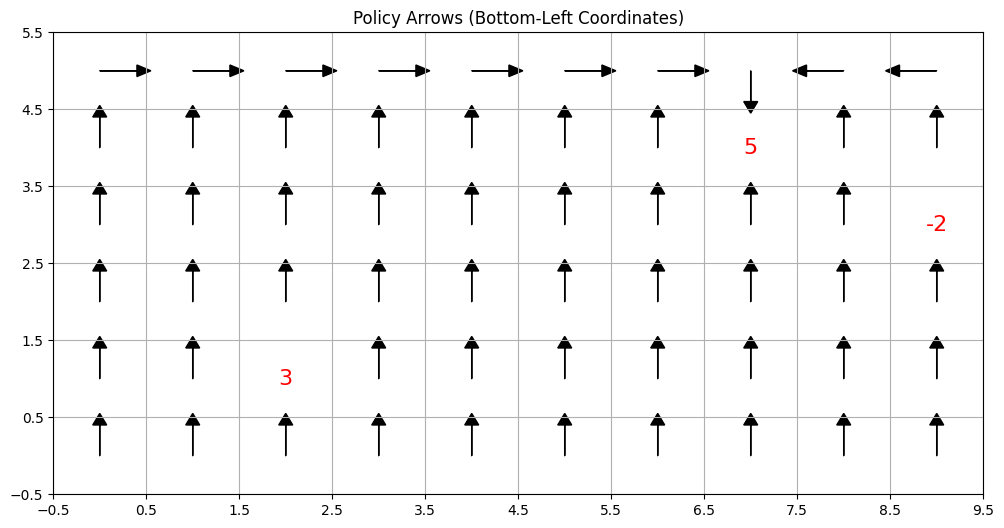

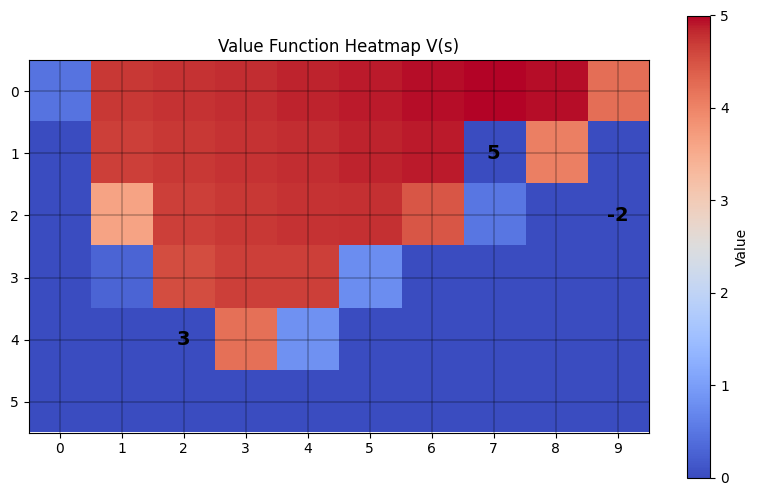

In [2]:
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Compute V(s) = max_a Q(s,a)
# -------------------------------------------------------
V = np.max(Q, axis=2)

# -------------------------------------------------------
# 2. Plot Arrows (Policy)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title("Policy Arrows (Bottom-Left Coordinates)")
ax.set_xlim(-0.5, env.W - 0.5)
ax.set_ylim(-0.5, env.H - 0.5)

arrow_dx = {0: 0, 1: 0, 2: -0.4, 3: 0.4}
arrow_dy = {0: 0.4, 1: -0.4, 2: 0, 3: 0}

for x in range(env.W):
    for y in range(env.H):

        if (x, y) in env.rewards:
            # Mark terminal states
            ax.text(x, y, f"{env.rewards[(x,y)]}", fontsize=16, ha="center", va="center", color="red")
            continue

        a = np.argmax(Q[x, y])

        ax.arrow(x, y,
                 arrow_dx[a], arrow_dy[a],
                 head_width=0.15, head_length=0.15,
                 fc="black", ec="black")

# Draw grid lines
ax.set_xticks(np.arange(-0.5, env.W, 1))
ax.set_yticks(np.arange(-0.5, env.H, 1))
ax.grid(True)

plt.show()

# -------------------------------------------------------
# 3. Heatmap Visualization of V(s)
# -------------------------------------------------------
# Convert V to matrix with top row first (for plotting)
V_plot = np.zeros((env.H, env.W))
for x in range(env.W):
    for y in range(env.H):
        r, c = coord_to_index(x, y, env.H)
        V_plot[r, c] = V[x, y]

plt.figure(figsize=(10, 6))
plt.title("Value Function Heatmap V(s)")
plt.imshow(V_plot, cmap="coolwarm", origin="upper")
plt.colorbar(label="Value")

# Draw grid lines
plt.xticks(np.arange(env.W))
plt.yticks(np.arange(env.H))
plt.grid(which="both", color="black", linewidth=0.3)

# Show reward cells
for (x, y), rew in env.rewards.items():
    r, c = coord_to_index(x, y, env.H)
    plt.text(c, r, f"{rew}", ha="center", va="center", color="black", fontsize=14, fontweight="bold")

plt.show() 

In [3]:
# with the blocked grid


Policy Arrows (bottom-left coordinate system):

[['→' '→' '→' '→' '→' '→' '→' '↓' '↓' '↓']
 ['↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '←' '←']
 ['↑' '↑' '↑' '↑' '↑' '↑' 'X' '↑' '↑' '↑']
 ['↑' '↓' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']
 ['↑' '←' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']
 ['↑' '←' '↑' '↑' '↑' '↑' '↑' '↑' '↑' '↑']]


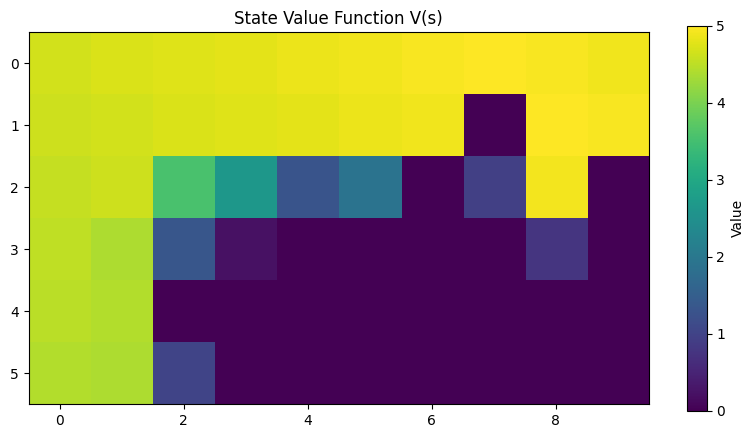

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Environment Setup (BOTTOM-LEFT COORDINATE SYSTEM)
# =========================================================

GRID_W = 10
GRID_H = 6

# Rewards
reward_map = np.zeros((GRID_H, GRID_W))
reward_map[4, 2] = 3     # (3)
reward_map[1, 7] = 5     # (5)
reward_map[2, 9] = -2    # (-2)

# Blocked cell at (6,3) -> convert to internal indices
# User coordinate (6,3) -> internal row = GRID_H-1 - y
def to_index(x, y):
    return GRID_H - 1 - y, x

blocked = {to_index(6, 3)}  # one blocked cell


# =========================================================
# 2. ACTIONS AND COORDINATE CONVERSION
# =========================================================

actions = [(0,1),  # up
           (1,0),  # right
           (0,-1), # down
           (-1,0)] # left

# convert internal row/col -> user (x,y)
def to_xy(r, c):
    return c, GRID_H - 1 - r

# convert user (x,y) -> internal row/col
def to_index(x, y):
    return GRID_H - 1 - y, x


# =========================================================
# 3. STEP FUNCTION WITH BLOCKED CELLS
# =========================================================

def step(state, action_idx):
    (r, c) = state

    if (r, c) in blocked:
        return (r, c), -5, True  # blocked cell = terminal penalty

    dx, dy = actions[action_idx]
    nx, ny = to_xy(r, c)
    nx += dx
    ny += dy

    # Check boundaries
    if nx < 0 or nx >= GRID_W or ny < 0 or ny >= GRID_H:
        return (r, c), -1, False  # bump into wall

    nr, nc = to_index(nx, ny)

    if (nr, nc) in blocked:
        return (r, c), -1, False

    reward = reward_map[nr, nc]
    done = (reward != 0)

    return (nr, nc), reward, done


# =========================================================
# 4. Q-LEARNING SETUP
# =========================================================

Q = np.zeros((GRID_H, GRID_W, len(actions)))

alpha = 0.1
gamma = 0.99
epsilon = 0.1
episodes = 5000
max_steps = 200  # you were missing this

start_state = to_index(0, 0)  # bottom-left


# =========================================================
# 5. TRAINING LOOP
# =========================================================

for ep in range(episodes):
    state = start_state
    for _ in range(max_steps):

        r, c = state

        # epsilon-greedy
        if np.random.rand() < epsilon:
            action = np.random.choice(len(actions))
        else:
            action = np.argmax(Q[r, c])

        next_state, reward, done = step(state, action)

        nr, nc = next_state

        # Q update
        Q[r, c, action] += alpha * (reward + gamma * np.max(Q[nr, nc]) - Q[r, c, action])

        state = next_state
        if done:
            break


# =========================================================
# 6. COMPUTE V(s) AND POLICY ARROWS
# =========================================================

V = np.max(Q, axis=2)

arrow_map = np.empty((GRID_H, GRID_W), dtype=object)
arrow_symbols = ["↑", "→", "↓", "←"]

for r in range(GRID_H):
    for c in range(GRID_W):
        if (r, c) in blocked:
            arrow_map[r, c] = "X"
        else:
            arrow_map[r, c] = arrow_symbols[np.argmax(Q[r, c])]


# =========================================================
# 7. DISPLAY POLICY + HEATMAP
# =========================================================

print("\nPolicy Arrows (bottom-left coordinate system):\n")
print(arrow_map)


plt.figure(figsize=(10,5))
plt.title("State Value Function V(s)")
plt.imshow(V, cmap="viridis")
plt.colorbar(label="Value")
plt.show()
